In [1]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sahi.models.ultralytics import UltralyticsDetectionModel
from sahi.predict import get_sliced_prediction
from ultralytics import YOLO

In [2]:
# Cargar modelo ya entrenado en colab
"""
model = YOLO('yolo26n.pt')

model.train(data='/content/Aircraft-Surface-Defect-Detection-3/data.yaml',
            epochs=100,
            imgsz=640,
            patience=10,
            batch=64)
"""
model = YOLO("runs/detect/train9/weights/best.pt")

In [3]:

def sahi(img, show=True):
    detection_model = UltralyticsDetectionModel(
    model_path='runs/detect/train9/weights/best.pt',
    confidence_threshold=0.25,
    device='cpu'
    )

    result_sahi = get_sliced_prediction(
        img,
        detection_model,
        slice_height=int(img.shape[0]/3),
        slice_width=int(img.shape[0]/3),
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    if len(result_sahi.object_prediction_list) > 0:
        print(f"Detectado con SAHI: {len(result_sahi.object_prediction_list)} objetos")
        # Normalizamos las coordenadas de SAHI a la misma lista [x1, y1, x2, y2]
        best_pred = result_sahi.object_prediction_list[0]
        final_coords = [
            best_pred.bbox.minx, 
            best_pred.bbox.miny, 
            best_pred.bbox.maxx, 
            best_pred.bbox.maxy
        ]

        if show:
            result_sahi.export_visuals(export_dir="outputs/", file_name="result_sahi")
            # SAHI suele guardar como 'result_sahi.png' en la carpeta indicada
            viz_img = mpimg.imread("outputs/result_sahi.png")
            plt.imshow(viz_img)
        
        return final_coords


image 1/1 c:\Users\pedro\Proyectitos\IndraStrike\fotos_prueba\Avin Cessna daado en la pista.png: 448x640 (no detections), 140.0ms
Speed: 144.9ms preprocess, 140.0ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
No se ha encontrado nada en la imagen completa. Dividiendo con SAHI...
Performing prediction on 24 slices.
Detectado con SAHI: 1 objetos
Cuadro encontrado por sahi:  [749.8489074707031, 473.0925598144531, 886.2957763671875, 614.0]


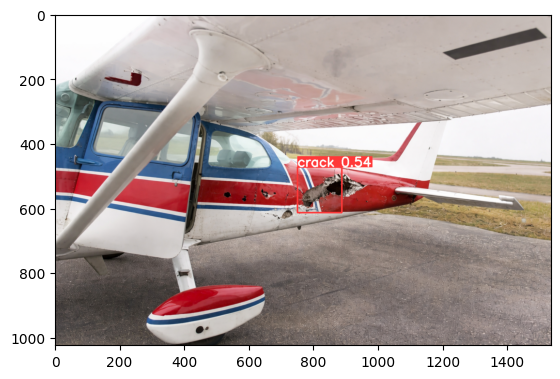

In [4]:
def detect_strike(dir_imagen, save=False, show=False):
    img = cv2.imread(dir_imagen)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    final_coords = None  # Aquí guardaremos [x1, y1, x2, y2]
    
    # Intento 1: YOLO Normal (Imagen completa)
    results = model.predict(dir_imagen, save=save, imgsz=640)

    if len(results[0].boxes) > 0: #type: ignore
        print("Se han detectado daños con YOLO estándar")
 
        box = results[0].boxes.xyxy[0].cpu().numpy() #type: ignore
        final_coords = [box[0], box[1], box[2], box[3]]
        
        if show:
            results[0].save("outputs/result.png")
            viz_img = mpimg.imread("outputs/result.png")
            plt.imshow(viz_img)

    # Intento 2: SAHI (Si YOLO falló)
    else:
        print("No se ha encontrado nada en la imagen completa. Dividiendo con SAHI...")
        
        coords = sahi(img_rgb, show=show)
        if coords != None:
            print("Cuadro encontrado por sahi: ", coords)

        else:
            print("Ni siquiera SAHI ha encontrado nada.")

    # 4. Mostrar y retornar si hay coordenadas
    if final_coords:
        print(f"Coordenadas finales normalizadas: {final_coords}")
        if show:
            plt.axis('off')
            plt.show()
        return final_coords
    
    return None

# Ejecución
coords = detect_strike("fotos_prueba/Avión Cessna dañado en la pista.png", show=True, save=False)